In [307]:
import scipy.stats as stats
# from bioinfokit.analys import stat,get_data
from statsmodels.stats.multitest import multipletests
import pandas as pd

scan_times = ['First','Second','Third','Fourth','Fifth']
var_name = ['cRAD','RAD','STD','CV','AC1','Hurst']

pat_all = []
ctr = pd.read_excel(f'F:\Matlab\Work\stroke_dynamics\RAD\Zeros_average_roi_Table.xls')
pat_all.append(ctr)
for i in scan_times:
    print('==> ==> ', i)
    pat = pd.read_excel(f'F:\Matlab\Work\stroke_dynamics\RAD\{i}_average_roi_Table.xls')
    # print(ac1)
    pat_all.append(pat)
    for var in var_name:
        tvalue, pvalue = stats.ttest_ind(pat[var],ctr[var])
        print(var,' ==> ',tvalue, pvalue )
#     break
# tvalue, pvalue = stats.ttest_ind(n_ac1['AC1'][:30],ac1['AC1'][30:])
# print(tvalue, pvalue)

==> ==>  First
cRAD  ==>  -2.188153756859414 0.03716432223767463
RAD  ==>  2.757821283502339 0.010131184732161142
STD  ==>  5.572837112781517 5.811127136899314e-06
CV  ==>  0.9625851131619235 0.343995727109509
AC1  ==>  -3.72421725614046 0.0008757218133965159
Hurst  ==>  27.559168083347878 7.842565156407912e-22
==> ==>  Second
cRAD  ==>  -1.9352442842796123 0.06311917549371783
RAD  ==>  2.446677557582738 0.020954246638741892
STD  ==>  5.492734940261411 7.225605911715944e-06
CV  ==>  1.0394400517450242 0.3074931835997109
AC1  ==>  -4.079110752826569 0.0003397712465412569
Hurst  ==>  31.616126759456495 1.8831079275714857e-23
==> ==>  Third
cRAD  ==>  -2.616777907018495 0.014149692100257308
RAD  ==>  2.4114735285088043 0.022694289668837807
STD  ==>  6.541026136126802 4.323211077320206e-07
CV  ==>  0.9492950046028675 0.3505928338370411
AC1  ==>  -4.9236936372723585 3.416801003941147e-05
Hurst  ==>  29.54044433342278 1.1950571130710775e-22
==> ==>  Fourth
cRAD  ==>  -2.238452164477908 0.033

In [ ]:
times = ['CTR']*15+['PAT1']*15+['PAT2']*15+['PAT3']*15+['PAT4']*15+['PAT5']*15
Subj =  [str(i) for i in range(15)]*6
print(Subj)

pat_all_df = pd.concat(pat_all)
pat_all_df.insert(0,'Subj',Subj)
pat_all_df.insert(0,'Times',times)

print(pat_all_df)
pat_all_df.to_csv('pat_all_df.csv')

   Times Subj      cRAD       RAD       STD            CV       AC1     Hurst
0    CTR    0 -1.972799 -0.158061  0.301458 -1.967703e+09  0.846588  0.036801
1    CTR    1 -1.745048  0.001677  0.168132 -4.132365e+09  0.851024  0.056192
2    CTR    2 -1.681189 -0.046637  0.212321  7.238483e+08  0.850803  0.173858
3    CTR    3 -1.250262 -0.052347  0.213736  1.533361e+09  0.891721  0.078545
4    CTR    4 -1.771581 -0.040245  0.275179 -1.656666e+09  0.855183  0.033457
..   ...  ...       ...       ...       ...           ...       ...       ...
10  PAT5   10 -1.882510 -0.200812  0.616876  1.378024e+14  0.700415  0.644212
11  PAT5   11 -3.274352  0.281672  1.292079  3.135051e+13  0.454908  0.794312
12  PAT5   12 -2.255357 -0.283136  0.470661 -2.859798e+13  0.618793  0.757898
13  PAT5   13 -1.846647 -0.130758  0.570868 -2.562206e+12  0.672462  0.782812
14  PAT5   14 -2.279568  0.066779  0.437663 -2.060825e+13  0.630982  0.672344

[90 rows x 8 columns]


# Good and bad patients comparison

In [178]:
import scipy.stats as stats
# from bioinfokit.analys import stat,get_data
from statsmodels.stats.multitest import multipletests
import pandas as pd

scan_times = ['First','Second','Third','Fourth','Fifth']
var_name = ['cRAD','RAD','STD','CV','AC1','Hurst']

poor_recovery = np.array([0,4,5,6,7,8,9,11,14])
good_recovery = np.array([1,2,3,10,12,13])

pat_all = []
for i in scan_times:
    print('==> ==> ', i)
    pat = pd.read_excel(f'F:\Matlab\Work\stroke_dynamics\RAD\{i}_average_roi_Table.xls') 
    pat.insert(0,'Subj',range(0,15))
    for var in var_name:
        good_df = pat[pat['Subj'].isin( good_recovery)]
        poor_df = pat[pat['Subj'].isin( poor_recovery)]
        tvalue, pvalue = stats.ttest_ind(good_df[var].values,poor_df[var].values)
        print(var,' ==> ',tvalue, pvalue)
    # break
# tvalue, pvalue = stats.ttest_ind(n_ac1['AC1'][:30],ac1['AC1'][30:])
# print(tvalue, pvalue)

==> ==>  First
cRAD  ==>  0.3318130463125999 0.7453190987769749
RAD  ==>  -0.17805833792682835 0.8614218509450563
STD  ==>  0.4504255130522491 0.659823861447703
CV  ==>  1.390248419065553 0.18779831628960783
AC1  ==>  -0.1581870166868326 0.8767402395069057
Hurst  ==>  0.22957853081795304 0.8219919360847215
==> ==>  Second
cRAD  ==>  0.9552137397710186 0.3568958278472738
RAD  ==>  -0.9892769409928841 0.340584076153833
STD  ==>  -1.185975221217866 0.2568565208942751
CV  ==>  -0.5938558875460092 0.562800053452335
AC1  ==>  -0.1386660054002316 0.8918390956909759
Hurst  ==>  -1.2462616156049122 0.23465916213468405
==> ==>  Third
cRAD  ==>  0.6568347459916521 0.5227456065308377
RAD  ==>  -1.487997015256914 0.16060304795693092
STD  ==>  -2.7259111426602787 0.017316434648534912
CV  ==>  0.4653636214939469 0.6493706648888735
AC1  ==>  0.04037552168322284 0.9684072437472955
Hurst  ==>  -2.5921727376649355 0.022335166180567058
==> ==>  Fourth
cRAD  ==>  0.5119811749280343 0.6172503887202931
RAD  

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy as sp
import matplotlib.font_manager as font_manager
import numpy as np


def add_sig_star(x1, x2, y, h, p_val, ax):
    bar_x = [x1, x1, x2, x2]
    bar_y = [y, y+h, y+h, y]
    ax.plot(bar_x, bar_y, c='black', linewidth=1.5)
    if p_val < 0.001:
        text = '***'
    elif p_val < 0.01:
        text = '**'
    elif p_val < 0.05:
        text = '*'
    else:
        text = 'ns'
    ax.text((x1 + x2) * 0.5, y , text, ha='center', va='bottom', fontsize=14)
    
scan_times2 = ['PAT1','PAT2','PAT3','PAT4','PAT5']
# Vars = 'AC1'
for var in var_name:
    for times in scan_times2:
        pat1 = pat_all_df[pat_all_df['Times'] == times]
        # print(pat1)
        # print(pat1[pat1['Recovery'] =='Good'][var].values)
        tvalue, p1 = stats.ttest_ind(pat1[pat1['Recovery'] =='Good'][var].values,pat1[pat1['Recovery'] =='Poor'][var].values)
        
        if p1< 0.05:
            
            fig, ax = plt.subplots(figsize=(6, 4))
            ax = sns.stripplot(x= 'Recovery',
                               y= var,
                              jitter= True,
                              palette="Set1",
                              data = pat1,
                              size = 10,
                              edgecolor = 'k',
                              linewidth = 1.5,
                              alpha =0.6
                             )
            sns.boxplot(ax = ax, 
                        x= 'Recovery',
                        y= var,
                        palette='Set1',
                        width = 0.6,
                        saturation = 0.6,
                        linewidth = 1.8,
                        data = pat_all_df)
            
            y_max = pat_all_df[var].max()
            add_sig_star(0, 1, y_max + 0.2, 0.05, p1, ax)  # W1 vs W2
            ax.set_title(times)
            ax.set_xlabel('Group',fontsize = 16, font = 'arial')
            ax.set_ylabel(var, fontsize = 16,font = 'arial')
            plt.xticks(fontsize= 14)
            plt.yticks(fontsize= 14)
            # ax.set_yticks(np.arange(-4,3,1),fontsize = 16, font = 'arial')
            # ax.set_xticks(['CTR','PAT1','PAT2','PAT3','PAT4','PAT5'],fontsize = 16, font = 'arial')
            # plt.grid()
            font_prop = font_manager.FontProperties(size=12)
            # ax.legend(prop = font_prop)
            bwith = 2 
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.spines['bottom'].set_linewidth(bwith)
            ax.spines['left'].set_linewidth(bwith)


# Longitudinal TC

C:\Users\Administrator\AppData\Local\Temp\ipykernel_1880\1667789488.py:40: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  ax = sns.stripplot(x= 'Times',


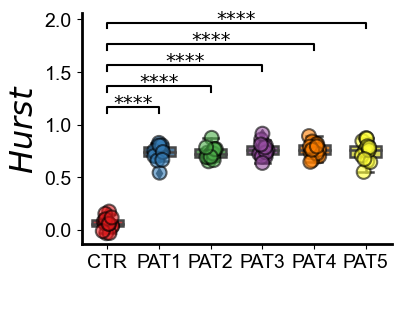

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy as sp
import matplotlib.font_manager as font_manager
import numpy as np

var = 'Hurst'
Ctr = pat_all_df[pat_all_df['Times'] == 'CTR'][var]
pat1 = pat_all_df[pat_all_df['Times'] == 'PAT1'][var]
pat2 = pat_all_df[pat_all_df['Times'] == 'PAT2'][var]
pat3 = pat_all_df[pat_all_df['Times'] == 'PAT3'][var]
pat4 = pat_all_df[pat_all_df['Times'] == 'PAT4'][var]
pat5 = pat_all_df[pat_all_df['Times'] == 'PAT5'][var]
tvalue, p1 = stats.ttest_ind(Ctr,pat1)
tvalue, p2 = stats.ttest_ind(Ctr,pat2)
tvalue, p3 = stats.ttest_ind(Ctr,pat3)
tvalue, p4 = stats.ttest_ind(Ctr,pat4)
tvalue, p5 = stats.ttest_ind(Ctr,pat5)


def add_sig_star(x1, x2, y, h, p_val, ax):
    bar_x = [x1, x1, x2, x2]
    bar_y = [y, y+h, y+h, y]
    ax.plot(bar_x, bar_y, c='black', linewidth=1.5)
    if p_val < 0.0001:
        text = '****'
    elif p_val < 0.001:
        text = '**'
    elif p_val < 0.01:
        text = '**'
    elif p_val < 0.05:
        text = '*'
    else:
        text = 'ns'
    ax.text((x1 + x2) * 0.5, y , text, ha='center', va='bottom', fontsize=14)


fig, ax = plt.subplots(figsize=(4, 3))
ax = sns.stripplot(x= 'Times',
                   y= var,
                   # hue= ' ', 
                  jitter= True,
                      # palette=['#F8F8FF','#000000'], # 黑白灰
                      # palette=['#67d294','#009a9c','#1f4620'], 
#                        palette=['#abeb88','#254b87','#dc7314'], 
#                        palette = 'BottleRocket1',
    #             palette=["silver", "salmon", "darkred"],
                  palette="Set1",
                  # dodge=True,
    #               legend =False,
                  data = pat_all_df,
                  size = 10,
                  edgecolor = 'k',
                  linewidth = 1.5,
                  alpha =0.6
                 )
sns.boxplot(ax = ax, 
            x= 'Times',
                   y= var,
            palette='Set1',
            width = 0.6,
            saturation = 0.6,
            linewidth = 1.8,
            data = pat_all_df)

y_max = pat_all_df[var].max()

add_sig_star(0, 1, y_max + 0.2, 0.05, p1, ax)  # W1 vs W2
add_sig_star(0, 2, y_max + 0.4, 0.05, p2, ax)  # W2 vs W3
add_sig_star(0, 3, y_max + 0.6, 0.05, p3, ax)  # W2 vs W3
add_sig_star(0, 4, y_max + 0.8, 0.05, p4, ax)  # W2 vs W3
add_sig_star(0, 5, y_max + 1.0, 0.05, p5, ax)  # W2 vs W3

# ax.set_title('Dynamics of Hub Regions: Slaves Vs. Master ')
fonts = 21
ax.set_xlabel(' ',fontsize = fonts+2,  family ='Arial')
ax.set_ylabel(f'${var}$', fontsize = fonts+2, family ='Arial')
plt.xticks(fontsize= 14,family ='Arial')
plt.yticks(fontsize= 14,family ='Arial')
# ax.set_yticks(np.arange(-4,3,1),fontsize = 16, font = 'arial')
# ax.set_xticks(['CTR','PAT1','PAT2','PAT3','PAT4','PAT5'],fontsize = 16, font = 'arial')
# plt.grid()
font_prop = font_manager.FontProperties(size=12)
# ax.legend(prop = font_prop)
bwith = 2 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_linewidth(bwith)
ax.spines['left'].set_linewidth(bwith)

plt.savefig(f'{var}.png', dpi = 400, bbox_inches='tight')

# Network

In [13]:
roi_networks = ['DMN1','DMN2','DMN3','DMN4','SMN1','SMN2','SMN3','VIS1','VIS2','VIS3','VIS4',"SAN1","SAN2","SAN3","SAN4"\
                ,"SAN5","SAN6","SAN7","DAN1","DAN2","DAN3"
          ,"DAN4","FPN1","FPN2","FPN3","FPN4","LN1","LN2","LN3","LN4","CE1","CE2"]
name_scan = ['CTR','PAT1','PAT2','PAT3','PAT4','PAT5']
net_index = [0,4,7,11,18,22,26,30,32] 
net_label = ['DMN','SMN','VIS','SAN','DAN','FPN','LN','CE'] 
network32_label = ['DMN','SMN','VIS','SAN','DAN','FPN','LN','CE']

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy as sp
import matplotlib.font_manager as font_manager
import numpy as np

network32_label = ['DMN','SMN','VIS','SAN','DAN','FPN','LN','CE']
net_rad = {}
net_rad['Subj'] = []
net_rad['Time_of_Scan'] = []
net_rad['Net'] = []
net_rad['Var'] = []
net_rad['Value'] = []

scan_times = ['Zeros','First','Second','Third','Fourth','Fifth']
n_subj = 15
var_name = ['cRAD','RAD','STD','CV','AC1','Hurst']

for num, time in enumerate(scan_times):
    pat_df = pd.read_excel(f'F:\Matlab\Work\stroke_dynamics\RAD\{time}_resultsTable.xls')
    # print(pat_df)
    # break
    for var in var_name:
        var_value = pat_df[var].values
        for i in range(n_subj):
            var_subj_value = var_value[i*32:(i+1)*32]
            # print(i*32,(i+1)*32)
            for net_ind,net in enumerate(net_label):
                net_rad['Net'].append(net)
                net_rad['Subj'].append(i)
                net_rad['Time_of_Scan'].append(time)
                net_rad['Var'].append(var)
                # print(net_index[net_ind],net_index[net_ind+1])
                # print(np.mean(var_subj_value[net_index[net_ind]:net_index[net_ind+1]]))
                net_rad['Value'].append(np.mean(var_subj_value[net_index[net_ind]:net_index[net_ind+1]]))

net_rad_df = pd.DataFrame(net_rad)
net_rad_df     

# Hierarchical TC after stroke

In [25]:
import seaborn as sns
import multiprocessing as mp
import matplotlib.font_manager as font_manager

# draw_violin_plot(ctr_sorted_df, 'ctr_net_rank_vio.png')
def draw_bar_plot(var,sorted_df,title,colormapss,savename):
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.barplot(data = sorted_df, x = 'Net', y = 'Value',capsize=.2,\
               palette = colormapss
               ) 
    # sorted_net_means = sorted_df.groupby("Net", sort = False)["INT"].median()
    font_prop = font_manager.FontProperties(size=12, family = 'Arial',weight= 'bold')
    plt.title(title,font_properties = font_prop)
    plt.xlabel("Networks",font_properties = font_prop)
    plt.ylabel(var,font_properties = font_prop)
    # plt.grid(True)

    plt.xticks(fontsize=12,font_properties = font_prop)
    plt.yticks(fontsize=12,font_properties = font_prop)
    # plt.legend(fontsize=12)

    bwith = 1 #边框宽度设置为2
    ax = plt.gca()#获取边框
    #设置边框
    ax.spines[['right', 'top']].set_visible(False)
    ax.spines['bottom'].set_linewidth(bwith)#图框下边
    ax.spines['left'].set_linewidth(bwith)#图框左边
    # ax.spines['top'].set_linewidth(bwith)#图框上边
    # ax.spines['right'].set_linewidth(bwith)#图框右边
    if savename:
        plt.savefig(savename, dpi = 300, bbox_inches='tight')

In [17]:
var = 'cRAD'
net_rad_df
colormap = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', \
            '#e377c2', '#7f7f7f']
scan_times2 = ['PAT1','PAT2','PAT3','PAT4','PAT5']

,Subj,Time_of_Scan,Net,Var,Value
0,0,Zeros,DMN,cRAD,-1.838692
1,0,Zeros,SMN,cRAD,-2.551992
2,0,Zeros,VIS,cRAD,-2.617475
3,0,Zeros,SAN,cRAD,-1.852436
4,0,Zeros,DAN,cRAD,-1.797287
...,...,...,...,...,...
3115,14,Fifth,SAN,cRAD,-2.012381
3116,14,Fifth,DAN,cRAD,-2.679734
3117,14,Fifth,FPN,cRAD,-1.940247
3118,14,Fifth,LN,cRAD,-2.073745


In [ ]:
var = 'cRAD'
net_int_df = net_rad_df[net_rad_df['Var'] == var].copy()
print(net_int_df)

ctr_net_df = net_int_df[net_int_df['Time_of_Scan'] == 'Zeros'].copy()
ctr_net_means = ctr_net_df.groupby("Net", sort = False)["Value"].mean()
ctr_net_order = ctr_net_means.sort_values(ascending=True).index
# print(ctr_net_means)
ctr_rank = np.argsort([np.mean(ctr_net_df[ctr_net_df['Net'] == net]['Value'].values) \
                       for net in network32_label])
ctr_net_df["Net"] = pd.Categorical(ctr_net_df["Net"], categories = ctr_net_order, ordered=True)
ctr_sorted_df = ctr_net_df.sort_values(by="Net").reset_index(drop=True)
# print(good_sorted_df)
colors =[colormap[i] for i in ctr_rank]
draw_bar_plot(var,ctr_net_df,'CTR',colors, ' ')


scan_times3 = ['First','Second','Third','Fourth','Fifth']

for num,scantime in enumerate(scan_times3):
    pat_net_df = net_int_df[net_int_df['Time_of_Scan'] == scantime].copy()
    ## good 
    pat_net_means = pat_net_df.groupby("Net", sort = False)["Value"].mean()
    pat_net_order = pat_net_means.sort_values(ascending=True).index
    # print(net_means)
    pat_rank = np.argsort([np.mean(pat_net_df[pat_net_df['Net'] == net]['Value'].values) \
                           for net in network32_label])
    pat_net_df["Net"] = pd.Categorical(pat_net_df["Net"], categories = pat_net_order, ordered=True)
    pat_sorted_df = pat_net_df.sort_values(by="Net").reset_index(drop=True)
    # print(good_sorted_df)
    colors =[colormap[i] for i in good_rank]
    
    ###################### 
    res = stats.spearmanr(pat_rank,ctr_rank)
    # res = stats.kendalltau(pat_rank,ctr_rank)
    print(f'==> ==> {scantime}', res)
    # if res.pvalue < 0.05:
    #     draw_bar_plot(var, pat_net_df, f'{scan_times2[num]}', colors, ' ')
    if num == 0:
        draw_bar_plot(var, pat_net_df, f'{scan_times2[num]}', colors, ' ')

# Modelling 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numba import jit
from numba import cuda
import numba
import time
import multiprocessing as mp
import matplotlib.font_manager as font_manager
import sys
from tqdm import tqdm
import scipy.io as scio
import os 
import sys
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

import math
from scipy import stats
from glob import *

In [2]:
import scipy.stats as stats
# from bioinfokit.analys import stat,get_data
from statsmodels.stats.multitest import multipletests
import pandas as pd
import os 
from scipy.stats import sem

rootPath = 'F:\Jupyter\Stroke_dynamics\modelling\\'
path_name = 'T_*_resultsTable.xls'
all_file_names = []
for root, dirs,files in os.walk(rootPath):
    print(root)
    for match in glob(os.path.join(root, path_name)):
        # print(match)
        all_file_names.append(match)

In [282]:
var = 'Hurst'

one_Rad_dfs = pd.read_excel(all_file_names[0])[var].copy()
print(one_Rad_dfs)

for num, onetrail in enumerate(all_file_names):
    if num == 0:
        continue
    one_Rad_df = pd.read_excel(onetrail)[var].copy()
    one_Rad_dfs = pd.concat((one_Rad_dfs,one_Rad_df), axis = 1)
    if num == 50:
        break
# print(one_Rad_dfs)

0      0.533535
1      0.259250
2      0.417741
3      0.583314
4      0.328781
         ...   
97     0.169438
98     0.137899
99     0.382222
100    0.185638
101    0.288122
Name: Hurst, Length: 102, dtype: float64


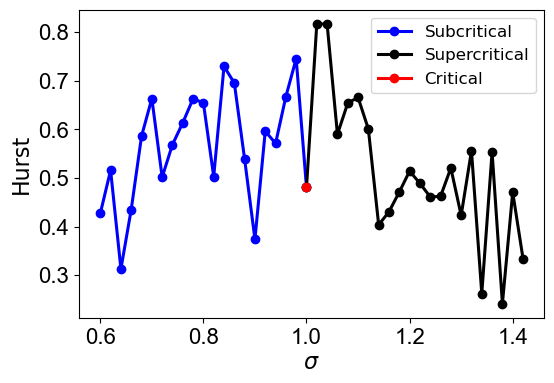

In [283]:
# one trial example
sigmas = np.arange(0.6,1.61, 0.01)
fig, ax = plt.subplots(figsize=(6, 4))

example_var = one_Rad_dfs.iloc[:,1]
s4 = np.concatenate((sigmas[:90][::2],sigmas[-21:][::3]),axis = 0)
t4 = np.concatenate((example_var[:90][::2],example_var[-21:][::3]),axis = 0)

# t5 = np.hstack((s4[:15],t4[16:]))
# s5 = np.hstack((s4[:15],s4[16:]))
ax.plot(s4[:21], t4[:21], color='blue', linewidth = 2.2, linestyle='-', marker = 'o', label = 'Subcritical')
ax.plot(s4[20:-10], t4[20:-10], color='black', linewidth = 2.2, linestyle='-', marker = 'o', label = 'Supercritical')
ax.plot(s4[20:21], t4[20:21], color='red', linewidth = 2.2, linestyle='-', marker = 'o', label = 'Critical')

ax.set_xlabel('$\sigma$',fontsize= 16, family ='Arial')
ax.set_ylabel(var,fontsize= 16)
# ax.set_title('travel frequency vs infected ratio(N = 1000)',fontsize=32)
plt.xticks(family ='Arial',fontsize= 16)
plt.yticks(fontsize= 16, family ='Arial')
# font_prop = font_manager.FontProperties(size = 14, weight = 4, family = 'Arial')
labels = ax.get_xticklabels() + ax.get_yticklabels()
ax.legend(fontsize = 12)
# plt.savefig(f'intvsfor1.png', dpi = 300, bbox_inches='tight')
plt.show()

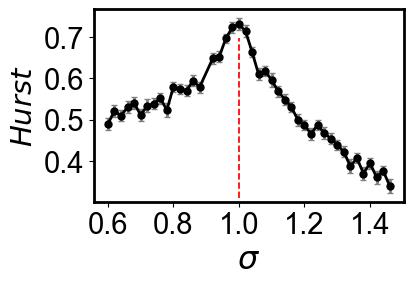

In [293]:
# average over trials

sigma = np.arange(0.6,1.61, 0.01)
all_Rad_agv = one_Rad_dfs.values.mean(axis = 1)
all_Rad_sem = sem(one_Rad_dfs.values,axis = 1)

# s2 = sigma
# t2 = all_Rad_agv
# sem2 = all_Rad_sem


fig, ax = plt.subplots(figsize=(4, 2.5))
s2 = np.concatenate((sigmas[:90][::2],sigmas[-21:][::3]),axis = 0)
t2 = np.concatenate((all_Rad_agv[:90][::2],all_Rad_agv[-21:][::3]),axis = 0)
sem2 = np.concatenate((all_Rad_sem[:90][::2], all_Rad_sem[-21:][::3]),axis = 0)

t3 = np.hstack((t2[:15],t2[16:]))
sem3 = np.hstack((sem2[:15],sem2[16:]))
s3 = np.hstack((s2[:15],s2[16:]))

ax.errorbar(s3[:-8],t3[:-8], yerr = sem3[:-8], color='black', capsize=2, ecolor= 'gray', linewidth= 2.0, linestyle='-', marker = 'o',ms = 5)

# plt.yticks(fontsize= 10)
ax.axvline(1,ymin = 0.02, ymax = 0.85, linestyle='--', linewidth= 1.25, color = 'red')
# ax.annotate(f'$\sigma = $ {round(s2[np.argmax(t2)],2)}',
#                         xy=(s2[np.argmax(t2)], t2.max()),
#                         xytext=(10,-4),  # 4 points vertical offset.
#                         textcoords='offset points')
# plt.xticks(fontsize= 10)
# plt.yticks(fontsize= 10)

fonts = 21
ax.set_xlabel('$\sigma$',fontsize= fonts+2, family ='Arial')
ax.set_ylabel(f'${var}$',fontsize= fonts,family ='Arial')
# ax.set_title('travel frequency vs infected ratio(N = 1000)',fontsize=32)
plt.xticks(family ='Arial',fontsize= fonts)
plt.yticks(fontsize= fonts,family ='Arial')
font_prop = font_manager.FontProperties(size = 14, weight = 4, family = 'Arial')
labels = ax.get_xticklabels() + ax.get_yticklabels()

bwith = 2 #边框宽度设置为2
ax = plt.gca()#获取边框
#设置边框
ax.spines['bottom'].set_linewidth(bwith)#图框下边
ax.spines['left'].set_linewidth(bwith)#图框左边

# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
ax.spines['top'].set_linewidth(bwith)#图框上边
ax.spines['right'].set_linewidth(bwith)#图框右边
plt.savefig(f"{var}.png",bbox_inches='tight', pad_inches=0, dpi=300)